# **Pipeline: Original Graph G → Generate Node Features X → Construct Graph Pair (Gs, Gt) + Ground Truth → Add Noise (Structural + Attributive) → Convert to Matrix Form (A, X) → Embedding / Representation Learning → Compute Similarity Matrix → Matching (Alignment) → Evaluation (Accuracy / Hit@k)**

## **Section 1. Environment Setup**

In [1]:
!pip install "numpy<2" node2vec
!pip install scikit-learn scipy pandas matplotlib torch networkx

## **Section 2. Path Configuration and Import**

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append(os.path.abspath("src"))

from data_utils import *
from noise_utils import *
from matching import *
from metrics import *
from baselines import *
from models import *
from experiment import *

SEED = 42
DATA_DIR = "data/raw"
EDGE_FILE = "twitter_edges_small.csv"

EMBED_DIM = 64
EDGE_NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3]
ATTR_NOISE_LEVELS = [0.0, 0.1, 0.2]
NUM_RUNS = 3

set_seed(SEED)

C:\Users\23293\anaconda3\envs\netalign\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Section 3. Load Twitter Graph**


In [3]:
G = load_base_graph(
    name="twitter",
    data_dir=DATA_DIR,
    edge_file=EDGE_FILE
)

print("Base graph loaded.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Base graph loaded.
Nodes: 2993
Edges: 50187


## **Section 4. Generate Node Features**

In [4]:
X = generate_node_features(G, feat_dim=16, mode="structural")
print("Feature shape:", X.shape)

Feature shape: (2993, 16)


## **Section 5. Construct Aligned Graph Pair**

In [5]:
Gs, Gt, Xs, Xt, gt_map = generate_permuted_graph_pair(G, X)

print("Source nodes:", Gs.number_of_nodes(), "edges:", Gs.number_of_edges())
print("Target nodes:", Gt.number_of_nodes(), "edges:", Gt.number_of_edges())
print("GT pairs:", len(gt_map))

As, src_nodes = graph_to_adjacency(Gs)
At, tgt_nodes = graph_to_adjacency(Gt)
gt_idx = build_gt_index_map(src_nodes, tgt_nodes, gt_map)

print("Adjacency shapes:", As.shape, At.shape)
print("GT index shape:", gt_idx.shape)

Source nodes: 2993 edges: 50187
Target nodes: 2993 edges: 50187
GT pairs: 2993
Adjacency shapes: (2993, 2993) (2993, 2993)
GT index shape: (2993,)


## **Section 6. Clean Baselines**

## 6.1 Node2Vec

In [6]:
(Zs, _), t1 = timed_run(node2vec_embed, Gs, EMBED_DIM)
(Zt, _), t2 = timed_run(node2vec_embed, Gt, EMBED_DIM)

sim = similarity_matrix(Zs, Zt)
pred = match_nearest_neighbor(sim)

print("Node2Vec Accuracy@1:", accuracy_at_1(pred, gt_idx))
print("Node2Vec Hit@1:", hit_at_k(sim, gt_idx, 1))
print("Node2Vec Hit@5:", hit_at_k(sim, gt_idx, 5))
print("Node2Vec Runtime:", t1 + t2)

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:17<00:00,  2.85it/s]


Node2Vec Accuracy@1: 0.0006682258603407952
Node2Vec Hit@1: 0.0006682258603407952
Node2Vec Hit@5: 0.0020046775810223854
Node2Vec Runtime: 139.19880270957947


## 6.2 FINAL

In [8]:
final = FINALAligner(alpha=0.8, max_iter=30).fit(As, At, Xs, Xt)
S = final.predict_score_matrix()
pred_final = final.predict_top1(use_hungarian=False)

print("FINAL Accuracy@1:", accuracy_at_1(pred_final, gt_idx))
print("FINAL Hit@1:", hit_at_k(S, gt_idx, 1))
print("FINAL Hit@5:", hit_at_k(S, gt_idx, 5))

FINAL Accuracy@1: 0.0006682258603407952
FINAL Hit@1: 0.0006682258603407952
FINAL Hit@5: 0.0023387905111927833


## 6.3 WAlign-style

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

As_t = torch.tensor(As, dtype=torch.float32, device=device)
At_t = torch.tensor(At, dtype=torch.float32, device=device)
Xs_t = torch.tensor(Xs, dtype=torch.float32, device=device)
Xt_t = torch.tensor(Xt, dtype=torch.float32, device=device)

model = LightGCNAlign(
    in_dim=Xs.shape[1],
    hidden_dim=64,
    out_dim=64,
    num_hops=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    stats = train_walign_epoch(model, As_t, Xs_t, At_t, Xt_t, optimizer)
    if epoch % 5 == 0:
        print(epoch, stats)

model.eval()
with torch.no_grad():
    Zs_t, Zt_t, _, _ = model(As_t, Xs_t, At_t, Xt_t)
    sim_t = torch.matmul(Zs_t, Zt_t.T).cpu().numpy()

pred_model = sim_t.argmax(axis=1)

print("WAlign-style Accuracy@1:", accuracy_at_1(pred_model, gt_idx))
print("WAlign-style Hit@1:", hit_at_k(sim_t, gt_idx, 1))
print("WAlign-style Hit@5:", hit_at_k(sim_t, gt_idx, 5))

0 {'loss': 1.9193875789642334, 'align_loss': 0.014016129076480865, 'rec_loss': 1.9053714275360107}
5 {'loss': 1.8869819641113281, 'align_loss': 0.011261233128607273, 'rec_loss': 1.875720739364624}
10 {'loss': 1.8631011247634888, 'align_loss': 0.009458865039050579, 'rec_loss': 1.853642225265503}
15 {'loss': 1.8451693058013916, 'align_loss': 0.007876096293330193, 'rec_loss': 1.837293267250061}
WAlign-style Accuracy@1: 0.0
WAlign-style Hit@1: 0.0
WAlign-style Hit@5: 0.0


## **Section 7. Noisy Baselines**

In [10]:
Gs_n, Gt_n, Xs_n, Xt_n = build_noisy_pair(
    Gs, Gt, Xs, Xt,
    edge_noise=0.1,
    attr_noise=0.1
)

As_n, src_nodes_n = graph_to_adjacency(Gs_n)
At_n, tgt_nodes_n = graph_to_adjacency(Gt_n)
gt_idx_n = build_gt_index_map(src_nodes_n, tgt_nodes_n, gt_map)

## 7.1 noisy Node2Vec

In [11]:
(Zs_n, _), t1_n = timed_run(node2vec_embed, Gs_n, EMBED_DIM)
(Zt_n, _), t2_n = timed_run(node2vec_embed, Gt_n, EMBED_DIM)

sim_n = similarity_matrix(Zs_n, Zt_n)
pred_nn_n = match_nearest_neighbor(sim_n)

print("Noisy Node2Vec Accuracy@1:", accuracy_at_1(pred_nn_n, gt_idx_n))
print("Noisy Node2Vec Hit@1:", hit_at_k(sim_n, gt_idx_n, 1))
print("Noisy Node2Vec Hit@5:", hit_at_k(sim_n, gt_idx_n, 5))
print("Noisy Node2Vec Runtime:", t1_n + t2_n)

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:15<00:00,  3.18it/s]


Noisy Node2Vec Accuracy@1: 0.0010023387905111927
Noisy Node2Vec Hit@1: 0.0010023387905111927
Noisy Node2Vec Hit@5: 0.005011693952555964
Noisy Node2Vec Runtime: 123.62977886199951


## 7.2 noisy FINAL

In [12]:
final_n = FINALAligner(alpha=0.8, max_iter=30).fit(As_n, At_n, Xs_n, Xt_n)
S_n = final_n.predict_score_matrix()
pred_final_n = final_n.predict_top1(use_hungarian=False)

print("Noisy FINAL Accuracy@1:", accuracy_at_1(pred_final_n, gt_idx_n))
print("Noisy FINAL Hit@1:", hit_at_k(S_n, gt_idx_n, 1))
print("Noisy FINAL Hit@5:", hit_at_k(S_n, gt_idx_n, 5))

Noisy FINAL Accuracy@1: 0.0013364517206815904
Noisy FINAL Hit@1: 0.0013364517206815904
Noisy FINAL Hit@5: 0.003341129301703976


## 7.3 noisy WAlign-style

In [13]:
As_n_t = torch.tensor(As_n, dtype=torch.float32, device=device)
At_n_t = torch.tensor(At_n, dtype=torch.float32, device=device)
Xs_n_t = torch.tensor(Xs_n, dtype=torch.float32, device=device)
Xt_n_t = torch.tensor(Xt_n, dtype=torch.float32, device=device)

model_n = LightGCNAlign(
    in_dim=Xs_n.shape[1],
    hidden_dim=64,
    out_dim=64,
    num_hops=2
).to(device)

optimizer_n = torch.optim.Adam(model_n.parameters(), lr=1e-3)

for epoch in range(20):
    stats_n = train_walign_epoch(model_n, As_n_t, Xs_n_t, At_n_t, Xt_n_t, optimizer_n)
    if epoch % 5 == 0:
        print(epoch, stats_n)

model_n.eval()
with torch.no_grad():
    Zs_n_t, Zt_n_t, _, _ = model_n(As_n_t, Xs_n_t, At_n_t, Xt_n_t)
    sim_t_n = torch.matmul(Zs_n_t, Zt_n_t.T).cpu().numpy()

pred_model_n = sim_t_n.argmax(axis=1)

print("Noisy WAlign-style Accuracy@1:", accuracy_at_1(pred_model_n, gt_idx_n))
print("Noisy WAlign-style Hit@1:", hit_at_k(sim_t_n, gt_idx_n, 1))
print("Noisy WAlign-style Hit@5:", hit_at_k(sim_t_n, gt_idx_n, 5))

0 {'loss': 1.7275081872940063, 'align_loss': 0.014435658231377602, 'rec_loss': 1.7130725383758545}
5 {'loss': 1.700317621231079, 'align_loss': 0.012472397647798061, 'rec_loss': 1.687845230102539}
10 {'loss': 1.6797194480895996, 'align_loss': 0.010917317122220993, 'rec_loss': 1.6688021421432495}
15 {'loss': 1.6640616655349731, 'align_loss': 0.009301970712840557, 'rec_loss': 1.6547596454620361}
Noisy WAlign-style Accuracy@1: 0.0003341129301703976
Noisy WAlign-style Hit@1: 0.0003341129301703976
Noisy WAlign-style Hit@5: 0.0006682258603407952


## **Section 8. Overall Batch Experiment**

In [14]:
df = run_experiments(
    G, X,
    edge_noise_levels=EDGE_NOISE_LEVELS,
    attr_noise_levels=ATTR_NOISE_LEVELS,
    runs=NUM_RUNS,
    embed_dim=EMBED_DIM
)

df.head()

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:14<00:00,  3.56it/s]


,method,edge_noise,attr_noise,run,acc,hit1,hit5,runtime
0,Node2Vec+NN,0.0,0.0,0,0.000668,0.000668,0.004678,133.683555
1,FINAL-style,0.0,0.0,0,0.000668,0.000668,0.002339,NaN
2,Node2Vec+NN,0.0,0.0,1,0.000668,0.000668,0.005346,133.662778
3,FINAL-style,0.0,0.0,1,0.000668,0.000668,0.002339,NaN
4,Node2Vec+NN,0.0,0.0,2,0.000334,0.000334,0.001336,131.580181


## **Section 9. Save Results**

In [15]:
os.makedirs("results", exist_ok=True)
df.to_csv("results/experiment_results.csv", index=False)
print("Saved to results/experiment_results.csv")

Saved to results/experiment_results.csv


## **Section 10. Plot Robustness Curves**

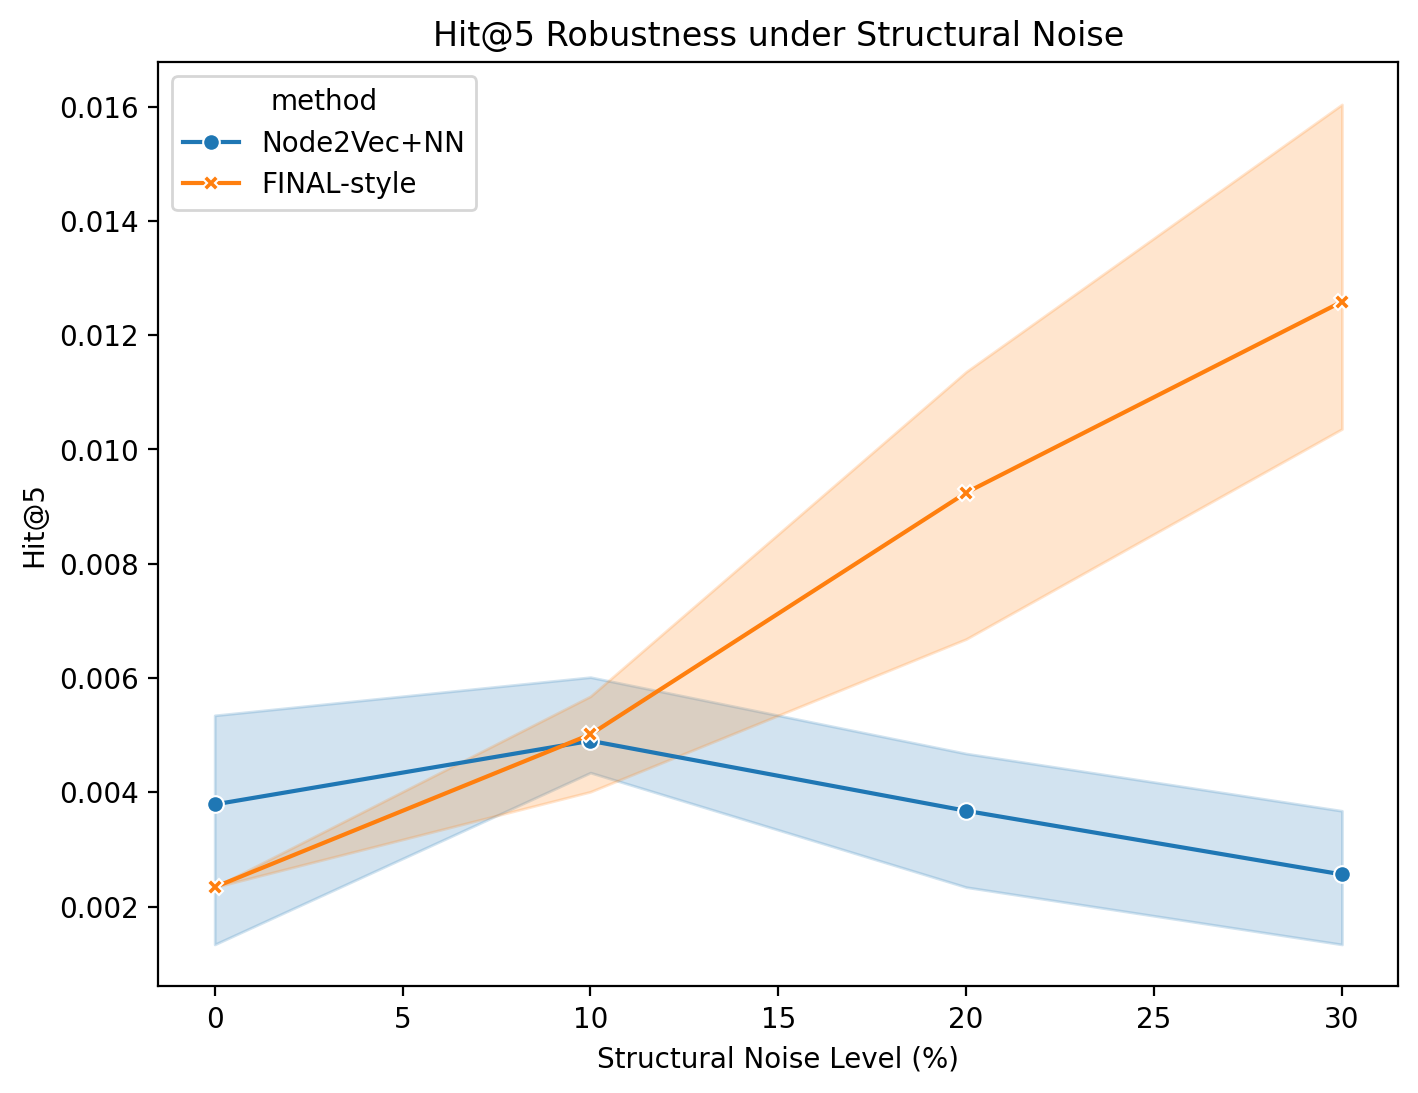

In [17]:
import seaborn as sns

df_plot = df[df["attr_noise"] == 0.0].copy()
df_plot["Noise_Level_Pct"] = df_plot["edge_noise"] * 100

plt.figure(figsize=(8, 6), dpi=200)
sns.lineplot(
    data=df_plot,
    x="Noise_Level_Pct",
    y="hit5",
    hue="method",
    style="method",
    markers=True,
    dashes=False
)
plt.title("Hit@5 Robustness under Structural Noise")
plt.xlabel("Structural Noise Level (%)")
plt.ylabel("Hit@5")
plt.show()

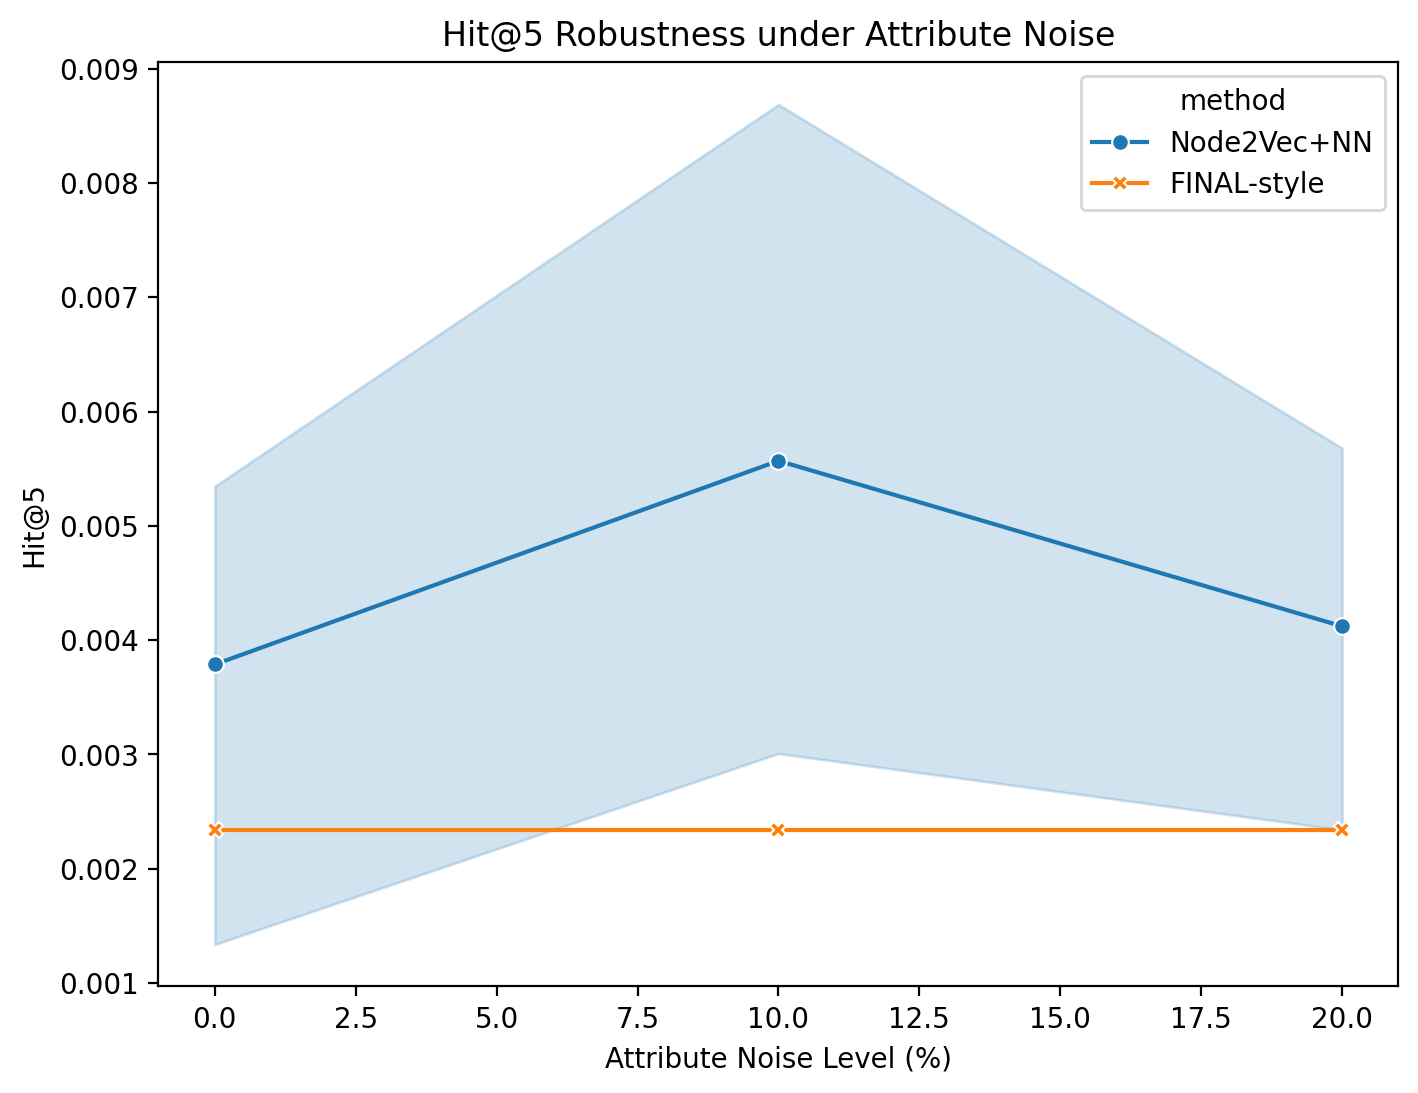

In [18]:
df_attr = df[df["edge_noise"] == 0.0].copy()
df_attr["Attr_Noise_Pct"] = df_attr["attr_noise"] * 100

plt.figure(figsize=(8, 6), dpi=200)
sns.lineplot(
    data=df_attr,
    x="Attr_Noise_Pct",
    y="hit5",
    hue="method",
    style="method",
    markers=True,
    dashes=False
)
plt.title("Hit@5 Robustness under Attribute Noise")
plt.xlabel("Attribute Noise Level (%)")
plt.ylabel("Hit@5")
plt.show()